# Mock Member Health Analysis - Feature Engineering

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


## 2. Load Raw Dataset



In [2]:
df = pd.read_csv("../data/processed/member_eda_ready.csv")
df.head()
# This notebook starts from the EDA-ready dataset created in Notebook 01 and adds additional engineered features for downstream analysis and modeling.

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,prior_awv_rate,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,0.333333,2,0,3920.62,1,Q4,65-79
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,0.000000,2,0,2446.74,0,Q1,18-34
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,1.000000,0,0,1419.49,1,Q4,80+
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,0.333333,2,1,3703.93,1,Q4,65-79
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,0.000000,0,0,471.10,1,Q4,35-49


## 3. Quick Validation

In [3]:
df.shape

(3000, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   member_id                3000 non-null   str    
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   region                   3000 non-null   str    
 4   plan_type                3000 non-null   str    
 5   sdoh_risk_score          3000 non-null   float64
 6   chronic_condition_count  3000 non-null   int64  
 7   engagement_score         3000 non-null   float64
 8   pcp_attributed_24mo      3000 non-null   int64  
 9   prior_awv_count          3000 non-null   int64  
 10  prior_awv_rate           3000 non-null   float64
 11  ed_visits                3000 non-null   int64  
 12  ip_admits                3000 non-null   int64  
 13  monthly_cost             3000 non-null   float64
 14  awv_completed            3000 non-n

In [5]:
df.isnull().sum() # Check for missing values in each column to assess data quality

member_id                  0
age                        0
gender                     0
region                     0
plan_type                  0
sdoh_risk_score            0
chronic_condition_count    0
engagement_score           0
pcp_attributed_24mo        0
prior_awv_count            0
prior_awv_rate             0
ed_visits                  0
ip_admits                  0
monthly_cost               0
awv_completed              0
engagement_group           0
age_group                  0
dtype: int64

In [6]:
df["member_id"].duplicated().sum() # Check for duplicate member IDs to ensure data integrity

np.int64(0)

## 4. Feature Engineering

In [7]:
df["age_group"] = pd.cut(df["age"], 
                        bins=[17, 34, 49, 64, 79, 100], 
                        labels=["18-34", "35-49", "50-64", "65-79", "80+"]) # Create age groups for better analysis and modeling



In [8]:
df["engagement_group"] = pd.qcut(
    df["engagement_score"],  # Split engagement score into quartiles
    q=4,  # Create four equal-sized groups
    labels=["Q1_Low", "Q2", "Q3", "Q4_High"]  # Label from lowest to highest engagement
)

### Create High-Cost Member Flag

`high_cost_member` is created from `monthly_cost` by flagging members in the top 25% of monthly cost.

This feature should be treated as a potential future **classification target**, not as a general predictor.

For example:
- Valid use: predicting whether a member becomes high-cost.
- Invalid use: using `high_cost_member` to predict `monthly_cost`, because it is directly derived from `monthly_cost` and would cause target leakage.

In [9]:
cost_threshold = df["monthly_cost"].quantile(0.75)  # Define high-cost threshold as top 25% of monthly cost
df["high_cost_member"] = (df["monthly_cost"] >= cost_threshold).astype(int)  # Binary high-cost label

In [10]:
df['chronic_burden_group'] = pd.cut(df['chronic_condition_count'],
                                        bins = [-1,1,3,8],
                                        labels = ['Low', 'Moderate', 'High']) # Create chronic burden groups based on the number of chronic conditions for better analysis and modeling

In [11]:
df["sdoh_risk_group"] = pd.qcut(
    df["sdoh_risk_score"],  # Split SDOH risk score into quartiles
    q=4,  # Create four equal-sized groups
    labels=["Q1_Low", "Q2", "Q3", "Q4_High"]  # Label from lowest to highest SDOH risk
)

In [12]:
df["prior_awv_group"] = pd.cut(
    df["prior_awv_count"],  # Use count of prior AWVs in the past 3 years
    bins=[-1, 0, 1, 2, 3],  # Separate 0, 1, 2, and 3 prior AWVs
    labels=["0", "1", "2", "3"]  # Label each prior AWV count group
)

In [13]:
df["total_acute_visits"] = (
    df["ed_visits"] + df["ip_admits"]
)  # Combine ED visits and inpatient admits into one acute utilization count

df["acute_utilization_group"] = pd.cut(
    df["total_acute_visits"],  # Use total acute visits
    bins=[-1, 0, 2, 5, 100],  # Define no, low, moderate, and high utilization
    labels=["None", "Low", "Moderate", "High"]  # Label acute utilization intensity
)

In [14]:
df["pcp_status"] = np.where(
    df["pcp_attributed_24mo"] == 1,  # Check whether member has PCP attribution
    "Attributed",  # Label attributed members
    "Not Attributed"  # Label non-attributed members
)

In [15]:
df["has_acute_utilization"] = (
    (df["ed_visits"] > 0) | (df["ip_admits"] > 0)
).astype(int)  # Flag members with at least one ED visit or inpatient admission

## 5. Validate New Features

In [16]:
df[[
    "age_group",
    "engagement_group",
    "sdoh_risk_group",
    "prior_awv_group",
    "high_cost_member",
    "has_acute_utilization",
    "total_acute_visits",
    "acute_utilization_group",
    "chronic_burden_group",
    "pcp_status"
]].head()  # Preview engineered features

,age_group,engagement_group,sdoh_risk_group,prior_awv_group,high_cost_member,has_acute_utilization,total_acute_visits,acute_utilization_group,chronic_burden_group,pcp_status
0,65-79,Q4_High,Q1_Low,1,1,1,2,Low,Moderate,Attributed
1,18-34,Q1_Low,Q4_High,0,0,1,2,Low,Moderate,Not Attributed
2,80+,Q4_High,Q2,3,0,0,0,None,Moderate,Attributed
3,65-79,Q4_High,Q1_Low,1,1,1,3,Moderate,High,Attributed
4,35-49,Q4_High,Q1_Low,0,0,0,0,None,Low,Not Attributed


In [17]:
df["age_group"].value_counts().sort_index() # Check the distribution of members across age groups to understand the demographic composition of the dataset


age_group
18-34    730
35-49    633
50-64    635
65-79    614
80+      388
Name: count, dtype: int64

In [18]:
df["engagement_group"].value_counts().sort_index()  # Check member distribution across engagement quartiles

engagement_group
Q1_Low     755
Q2         746
Q3         754
Q4_High    745
Name: count, dtype: int64

In [19]:
df["high_cost_member"].value_counts()

high_cost_member
0    2250
1     750
Name: count, dtype: int64

In [20]:
df["has_acute_utilization"].value_counts()

has_acute_utilization
1    2274
0     726
Name: count, dtype: int64

In [21]:
df["chronic_burden_group"].value_counts().sort_index()

chronic_burden_group
Low          919
Moderate    1431
High         650
Name: count, dtype: int64

The engineered feature distributions look reasonable. Quartile-based features are balanced by design, while clinically defined groups such as chronic burden and age group reflect the underlying synthetic population mix.

## 6. Refined Grouped Analysis

In [22]:
df.groupby("age_group", observed=True)["monthly_cost"].mean() # Analyze average monthly cost by age group to identify cost patterns across different age demographics

age_group
18-34    1594.246247
35-49    1662.838452
50-64    2114.688567
65-79    2943.931433
80+      2996.735361
Name: monthly_cost, dtype: float64

In [23]:
df.groupby("chronic_burden_group", observed=True)["monthly_cost"].mean() # Analyze average monthly cost by chronic burden group to identify cost patterns across different levels of chronic conditions

chronic_burden_group
Low         1301.796561
Moderate    2045.174577
High        3702.330923
Name: monthly_cost, dtype: float64

In [24]:
df.groupby("awv_completed")["has_acute_utilization"].mean() # Compare acute utilization rate by AWV completion status

awv_completed
0    0.798890
1    0.720154
Name: has_acute_utilization, dtype: float64

In [25]:
df.groupby("plan_type")["high_cost_member"].mean() # Analyze the relationship between plan type and high-cost member status to identify potential cost drivers


plan_type
DSNP                  0.362745
Medicaid              0.222736
Medicare Advantage    0.245598
Name: high_cost_member, dtype: float64

In [26]:
df.groupby("chronic_burden_group", observed=True)["high_cost_member"].mean() # Analyze the relationship between chronic burden group and high-cost member status to identify potential cost drivers related to chronic conditions

chronic_burden_group
Low         0.044614
Moderate    0.155835
High        0.747692
Name: high_cost_member, dtype: float64

In [27]:
df.groupby("chronic_burden_group", observed=True).agg(
    member_count=("member_id", "count"),
    avg_monthly_cost=("monthly_cost", "mean"),
    high_cost_rate=("high_cost_member", "mean")
)

,member_count,avg_monthly_cost,high_cost_rate
chronic_burden_group,,,
Low,919,1301.796561,0.044614
Moderate,1431,2045.174577,0.155835
High,650,3702.330923,0.747692


In [28]:
df.groupby("sdoh_risk_group", observed=True)[
    ["engagement_score", "ed_visits", "ip_admits", "monthly_cost"]
].mean()  # Check whether higher SDOH risk links to lower engagement and higher utilization/cost

,engagement_score,ed_visits,ip_admits,monthly_cost
sdoh_risk_group,,,,
Q1_Low,54.198267,0.897333,0.336000,2004.498733
Q2,46.579228,1.105193,0.438083,2085.199587
Q3,41.934483,1.212202,0.474801,2192.285650
Q4_High,35.468859,1.455034,0.539597,2425.729718


In [29]:
df.groupby("pcp_status", observed=True)[
    ["ed_visits", "ip_admits", "awv_completed", "monthly_cost"]
].mean()  # Check whether PCP attribution is associated with utilization, AWV completion, and cost

,ed_visits,ip_admits,awv_completed,monthly_cost
pcp_status,,,,
Attributed,1.050167,0.383278,0.640134,2037.305043
Not Attributed,1.283056,0.510299,0.399336,2314.777355


In [30]:
df.groupby("prior_awv_group", observed=True)[
    "awv_completed"
].mean()  # Check whether prior AWV history is associated with current AWV completion

prior_awv_group
0    0.357377
1    0.561385
2    0.645224
3    0.815287
Name: awv_completed, dtype: float64

In [31]:
df.groupby("acute_utilization_group", observed=True)[
    ["monthly_cost", "high_cost_member"]
].mean()  # Check whether acute utilization intensity relates to cost and high-cost status

,monthly_cost,high_cost_member
acute_utilization_group,,
None,1218.762906,0.035813
Low,2094.805677,0.199497
Moderate,3253.859968,0.562401
High,4929.798269,0.980769


## 7. Key Visualizations

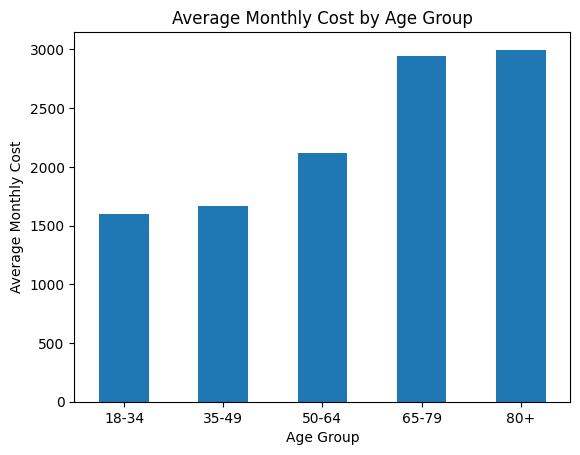

In [32]:
df.groupby("age_group", observed=True)["monthly_cost"].mean().plot(kind="bar", rot=0) # Visualize average monthly cost by age group to identify cost patterns across different age demographics
plt.title("Average Monthly Cost by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Monthly Cost")
plt.show()

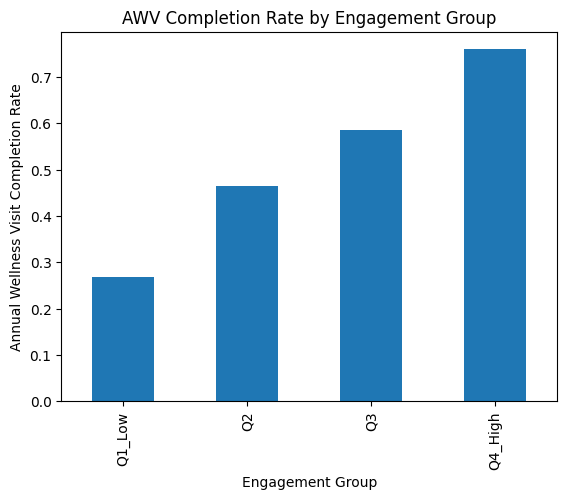

In [33]:
df.groupby("engagement_group", observed=True)["awv_completed"].mean().plot(kind="bar") # Visualize AWV completion rate by engagement group
plt.title("AWV Completion Rate by Engagement Group")  # Add plot title
plt.xlabel("Engagement Group")
plt.ylabel("Annual Wellness Visit Completion Rate")
plt.show()


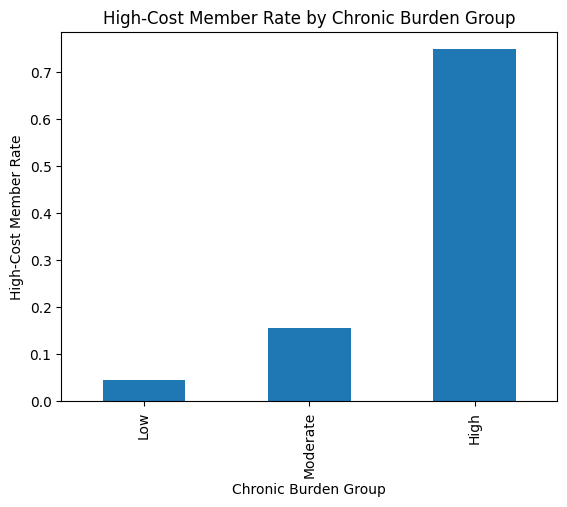

In [34]:
df.groupby("chronic_burden_group", observed=True)["high_cost_member"].mean().plot(kind="bar") # Analyze the relationship between chronic burden group and high-cost member status to identify potential cost drivers related to chronic conditions
plt.title("High-Cost Member Rate by Chronic Burden Group")
plt.xlabel("Chronic Burden Group")
plt.ylabel("High-Cost Member Rate")
plt.show()


## 8. Save Processed Dataset 

In [35]:
os.makedirs("../data/processed", exist_ok=True)  # Create processed data folder if it does not exist
df.to_csv("../data/processed/member_analysis_ready.csv", index=False)  # Save feature-engineered dataset for modeling notebooks

The exported dataset includes engineered features for analysis and future modeling. For future machine learning notebooks, data-driven transformations such as quartile grouping should be handled carefully to avoid preprocessing leakage.

## 9. Refined Findings

1. Average monthly cost increases across older age groups and higher chronic burden groups.
2. Members with higher chronic burden show substantially higher average cost and high-cost member rates.
3. AWV completion increases across higher engagement groups and stronger prior AWV history.
4. Higher SDOH risk groups show lower engagement and higher utilization/cost patterns.
5. PCP-attributed members show higher AWV completion, lower acute utilization, and lower average monthly cost than non-attributed members.
6. Members with higher acute utilization intensity show higher average monthly cost and higher high-cost member rates.
7. These relationships reflect synthetic data-generating assumptions and should be interpreted as simulated associations, not causal findings.


## 10. Data leakage / target leakage review

- high_cost_member -> High Risk -> Created directly from monthly_cost. Don't use it to predict monthly_cost

- engagement_group -> Medium -> Created using full-dataset quartiles. It is fine for EDA but risky for modeling if created before train/test split.

- sdoh_risk_group -> Medium -> Same qcut() issue as engagement_group

- acute_utilization_group -> Medium/High -> Could leak same-period utilization into same-period cost prediction.

- has_acute_utilization -> Medium/High -> Same timing issue as acute_utilization_group.

- prior_awv_group -> Medium -> Safe only if truly prior-period

- pcp_status -> Low/Medium -> Safe if known before outcome window.